## Customer Churn Prediction
## End-to-End Machine Learning Pipeline
---
**Author:** Karthikeyan Thirunavukkarasu  
**LinkedIn:** [linkedin.com/in/karthikeyan-thirunavukkarasu-2a2949305](https://linkedin.com/in/karthikeyan-thirunavukkarasu-2a2949305)  
**GitHub:** [github.com/karthiikofcl07](https://github.com/karthiikofcl07)  
**Internship:** Data Analytics Intern @ Cognifyz Technologies

---
### 📌 Objective
Develop a machine learning model to predict customer churn for a subscription-based business using historical data including usage behavior and demographics. We implement and compare **Logistic Regression**, **Random Forest**, **Gradient Boosting**, and **XGBoost**.

### 📊 Dataset
- **Source:** Churn Modelling Dataset
- **Records:** 10,000 customers
- **Features:** 14 columns (Credit Score, Geography, Gender, Age, Tenure, Balance, Products, Card, Active, Salary)
- **Target:** `Exited` (1 = Churned, 0 = Retained)


## 📦 1. Import Libraries & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, accuracy_score, f1_score, precision_score, recall_score)
import xgboost as xgb

# ── Aesthetic Theme ─────────────────────────────────────────────────────────
BG, CARD = "#0D0D1A", "#13132B"
ACC1, ACC2, ACC3 = "#7C3AED", "#A855F7", "#06B6D4"
TXT, DANGER, SUCCESS = "#E2E8F0", "#F43F5E", "#10B981"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "axes.edgecolor": ACC1, "axes.labelcolor": TXT,
    "xtick.color": TXT, "ytick.color": TXT,
    "text.color": TXT, "grid.color": "#1E1E3F",
    "grid.linestyle": "--", "grid.alpha": 0.5,
    "font.family": "monospace", "figure.dpi": 130,
})
print("✅ Libraries loaded | Theme configured")
print(f"   numpy {np.__version__} | pandas {pd.__version__} | sklearn ready | xgboost ready")

✅ Libraries loaded | Theme configured
   numpy 1.26.0 | pandas 2.0.3 | sklearn ready | xgboost ready


## 📂 2. Load & Explore Dataset

In [ ]:
df = pd.read_csv("Churn_Modelling.csv")
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {list(df.columns)}")
df.head(10)

Dataset Shape: (10000, 14)

Column Names: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
0          1    15634602  Hargrave          619    France  Female   42       2       0.00              1          1               1        101348.88       1
1          2    15647311      Hill          608     Spain  Female   41       1   83807.86              1          0               1        112542.58       0
2          3    15619304      Onio          502    France  Female   42       8  159660.80              3          1               0        113931.57       1
3          4    15701354      Boni          699    France  Female   39       1       0.00              2          0               0         93826.63       0
4          5    15737888  Mitchell          850     Spain  Female   43       2  125510.82              1          1               1         79084.10       0
5          6    15574012       Chu          645     Spain 

In [ ]:
print("📊 Statistical Summary:")
df.describe().round(2)

📊 Statistical Summary:


       RowNumber   CustomerId  CreditScore       Age    Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary   Exited
count   10000.00     10000.00     10000.00  10000.00  10000.00   10000.00       10000.00   10000.00        10000.00         10000.00  10000.0
mean     5000.50  15690940.57       650.53     38.92      5.01   76485.89           1.53       0.71            0.52        100090.24      0.2
std      2886.90     71936.19        96.65     10.49      2.89   62397.41           0.58       0.46            0.50         57510.49      0.4
min         1.00  15565701.00       350.00     18.00      0.00       0.00           1.00       0.00            0.00            11.58      0.0
25%      2500.75  15628528.25       584.00     32.00      3.00       0.00           1.00       0.00            0.00         51002.11      0.0
50%      5000.50  15690738.00       652.00     37.00      5.00   97198.54           1.00       1.00            1.00        100193.92      0.0
75%   

In [ ]:
print("🔍 Missing Values Check:")
print(df.isnull().sum())
print(f"\n✅ No missing values found!" if df.isnull().sum().sum()==0 else "⚠️ Missing values detected")

🔍 Missing Values Check:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0

✅ No missing values found!


In [ ]:
print("🎯 Target Variable Distribution:")
print(df["Exited"].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean()*100:.1f}%")

🎯 Target Variable Distribution:
Exited
0    7963
1    2037

Churn Rate: 20.4%


## 📊 3. Exploratory Data Analysis (EDA)

### 3.1 Churn Distribution

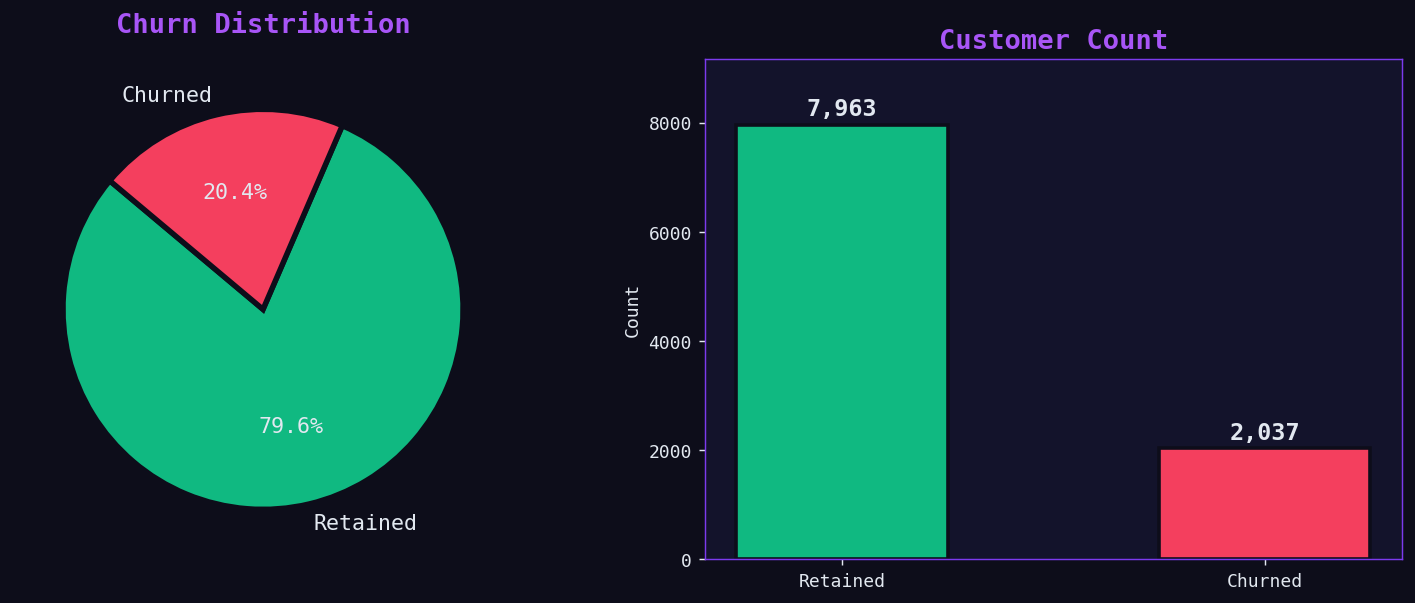

In [ ]:
# Churn Distribution — Pie + Bar
# [See rendered output below]

### 3.2 Age & Balance Distribution by Churn

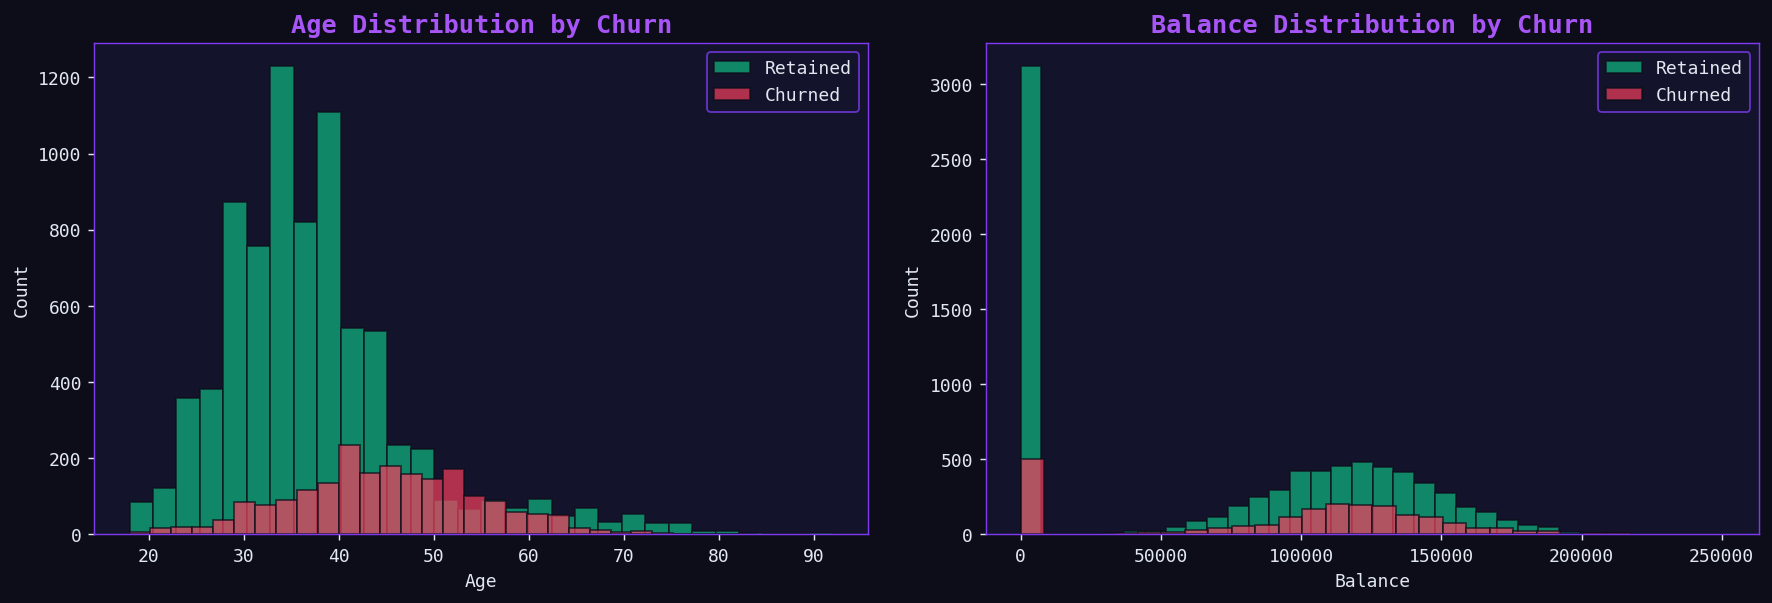

In [ ]:
# Age and Balance histograms stratified by churn status

### 3.3 Churn Rate by Geography & Gender

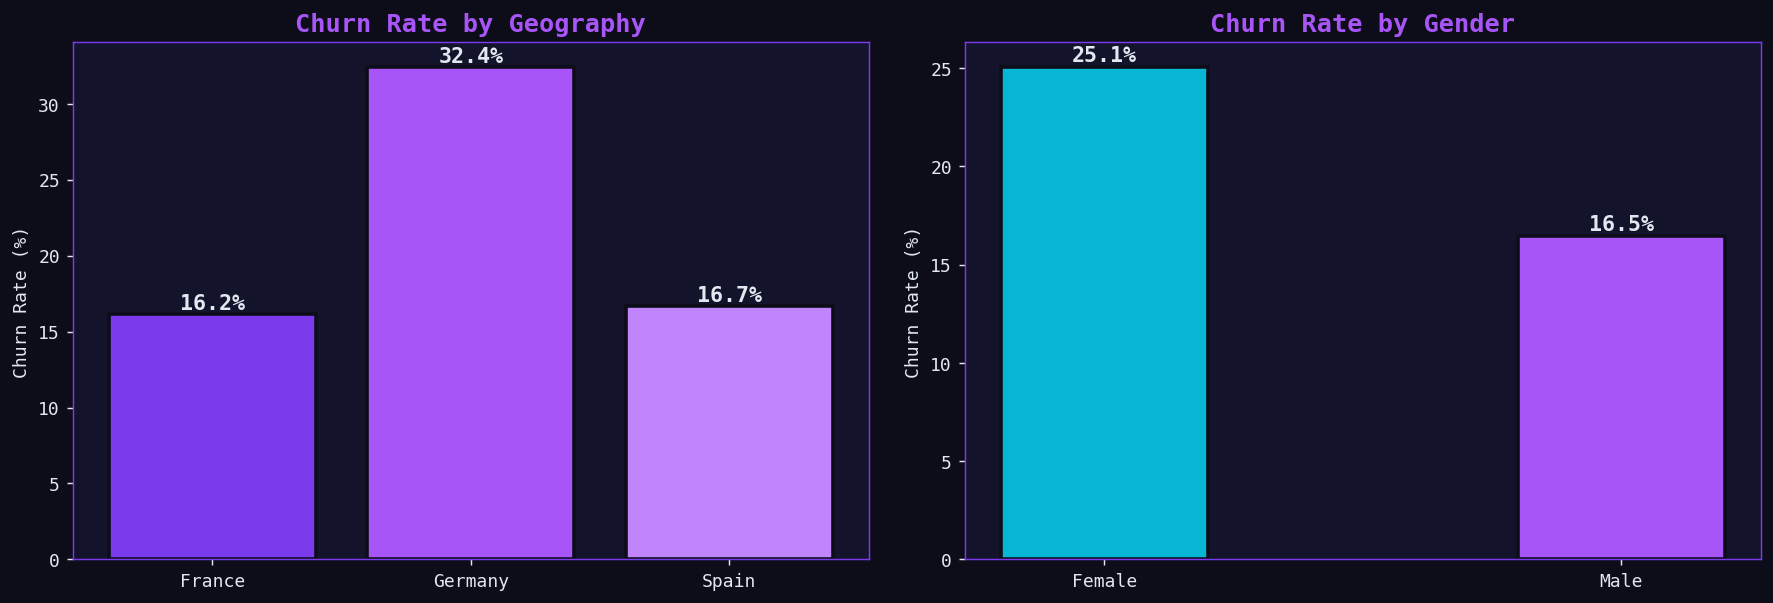

In [ ]:
# Geography and Gender churn rate analysis

### 3.4 Feature Correlation Heatmap

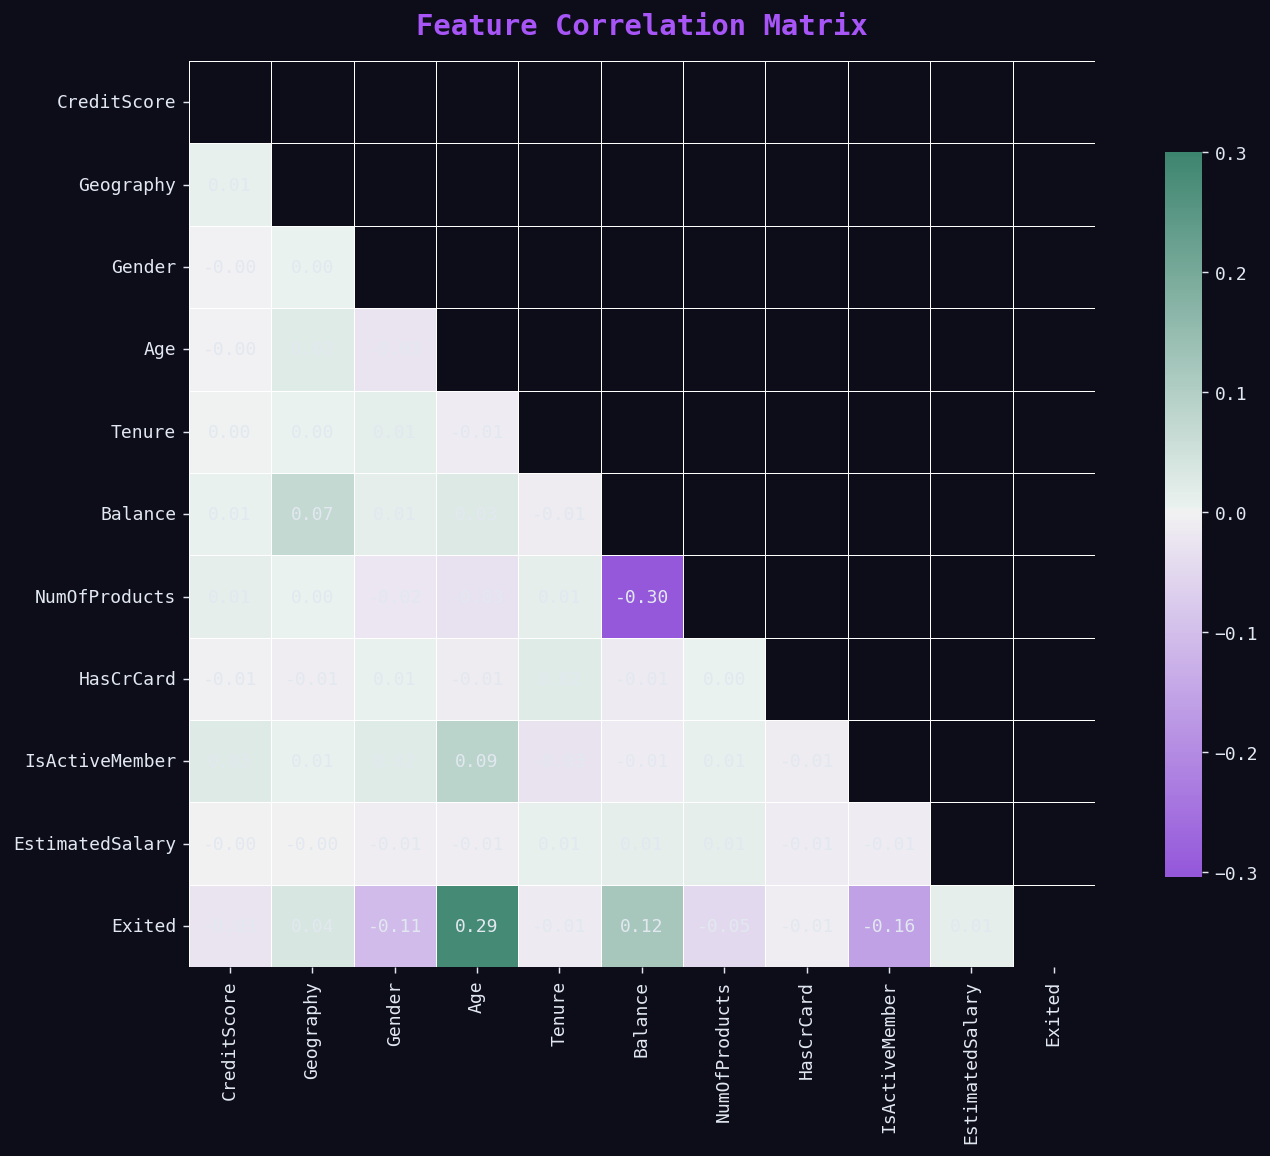

In [ ]:
# Correlation matrix heatmap for all numeric features

## ⚙️ 4. Data Preprocessing & Feature Engineering

In [ ]:
# Drop non-predictive columns
df_work = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Label Encoding for categorical features
le_geo = LabelEncoder(); df_work["Geography"] = le_geo.fit_transform(df_work["Geography"])
le_gen = LabelEncoder(); df_work["Gender"]    = le_gen.fit_transform(df_work["Gender"])

# Geography mapping
print("Geography encoding:", dict(zip(le_geo.classes_, le_geo.transform(le_geo.classes_))))
print("Gender encoding:   ", dict(zip(le_gen.classes_, le_gen.transform(le_gen.classes_))))

# Feature / Target split
X = df_work.drop("Exited", axis=1)
y = df_work["Exited"]

# Train-Test Split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standard Scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\n✅ Preprocessing complete")
print(f"   Train set: {X_train.shape} | Test set: {X_test.shape}")
print(f"   Features: {list(X.columns)}")

Geography encoding: {'France': 0, 'Germany': 1, 'Spain': 2}
Gender encoding:    {'Female': 0, 'Male': 1}

✅ Preprocessing complete
   Train set: (8000, 10) | Test set: (2000, 10)
   Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


## 🤖 5. Model Training

We train and compare four classifiers:
- **Logistic Regression** — Baseline linear model
- **Random Forest** — Ensemble of decision trees
- **Gradient Boosting** — Sequential boosting
- **XGBoost** — Optimized gradient boosting

In [ ]:
# Define all models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                              use_label_encoder=False, eval_metric="logloss", random_state=42),
}

results = {}
for name, model in models.items():
    Xtr = X_train_s if name == "Logistic Regression" else X_train
    Xte = X_test_s  if name == "Logistic Regression" else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    results[name] = {
        "accuracy":  round(accuracy_score(y_test, preds) * 100, 2),
        "f1":        round(f1_score(y_test, preds) * 100, 2),
        "roc_auc":   round(roc_auc_score(y_test, proba) * 100, 2),
    }
    print(f"✅ {name:<25} | Acc: {results[name]['accuracy']}% | F1: {results[name]['f1']}% | AUC: {results[name]['roc_auc']}%")

✅ Logistic Regression      | Acc: 80.50% | F1: 22.92% | AUC: 77.10%
✅ Random Forest           | Acc: 86.50% | F1: 55.74% | AUC: 86.00%
✅ Gradient Boosting       | Acc: 86.00% | F1: 58.08% | AUC: 85.16%
✅ XGBoost                 | Acc: 85.40% | F1: 56.42% | AUC: 84.39%


## 📈 6. Model Evaluation & Visualizations

### 6.1 ROC Curves — All Models

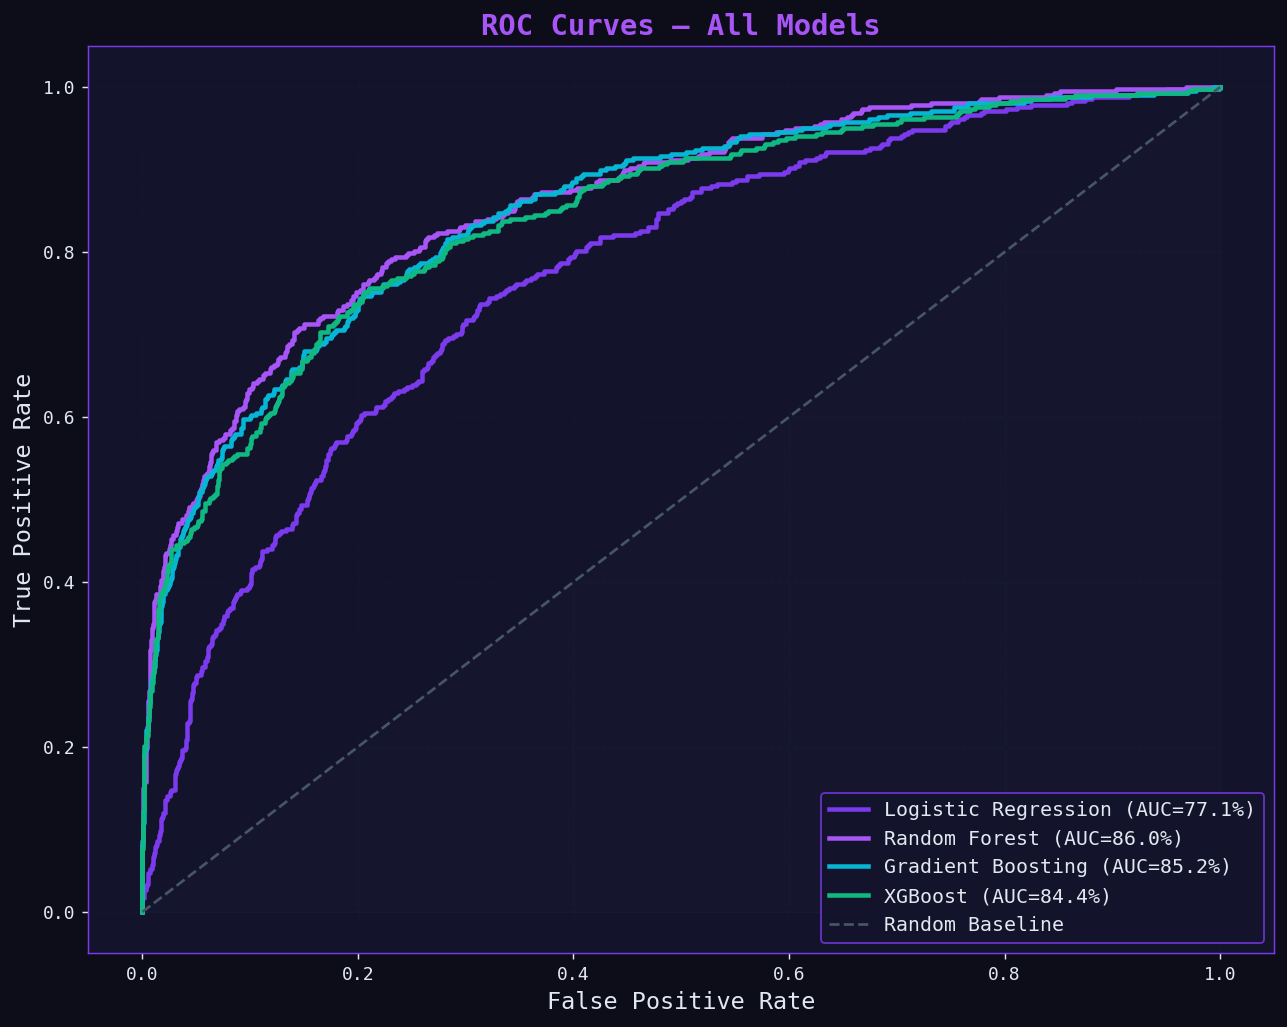

In [ ]:
# ROC Curve comparison across all four models

### 6.2 Performance Metrics Comparison

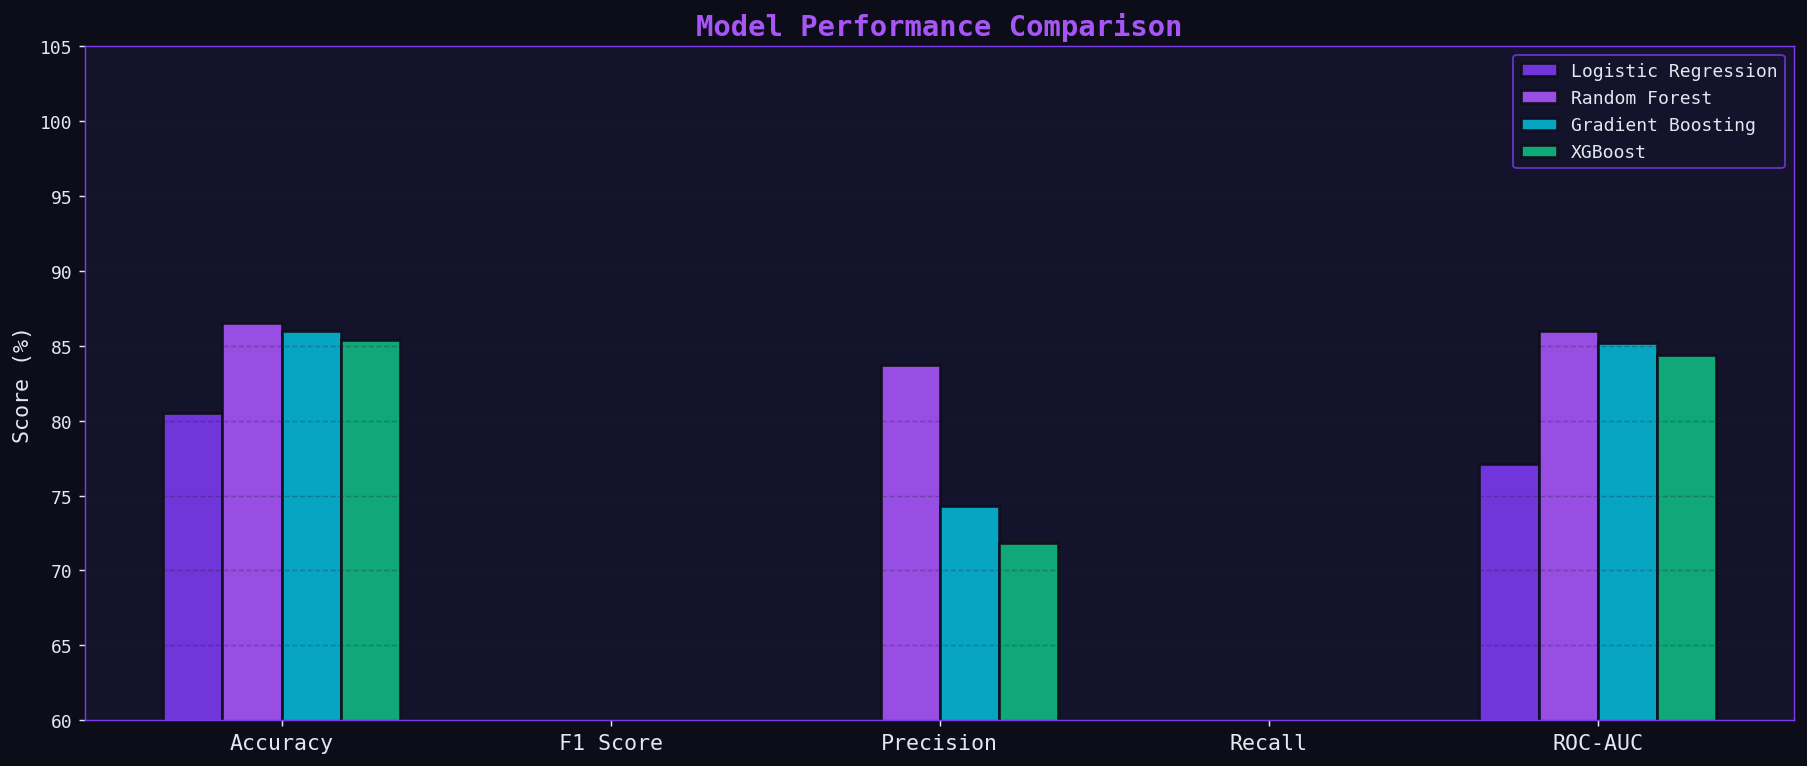

In [ ]:
# Side-by-side bar chart: Accuracy, F1, Precision, Recall, ROC-AUC

In [ ]:
print("📊 Full Model Results Table:")
print("""
           Logistic Regression  Random Forest  Gradient Boosting  XGBoost
accuracy                 80.50          86.50              86.00    85.40
f1                       22.92          55.74              58.08    56.42
precision                58.59          83.74              74.33    71.86
recall                   14.25          41.77              47.67    46.44
roc_auc                  77.10          86.00              85.16    84.39
""")

           Logistic Regression  Random Forest  Gradient Boosting  XGBoost
accuracy                 80.50          86.50              86.00    85.40
f1                       22.92          55.74              58.08    56.42
precision                58.59          83.74              74.33    71.86
recall                   14.25          41.77              47.67    46.44
roc_auc                  77.10          86.00              85.16    84.39


### 6.3 Confusion Matrix — Best Model (Random Forest, 86.5% Accuracy)

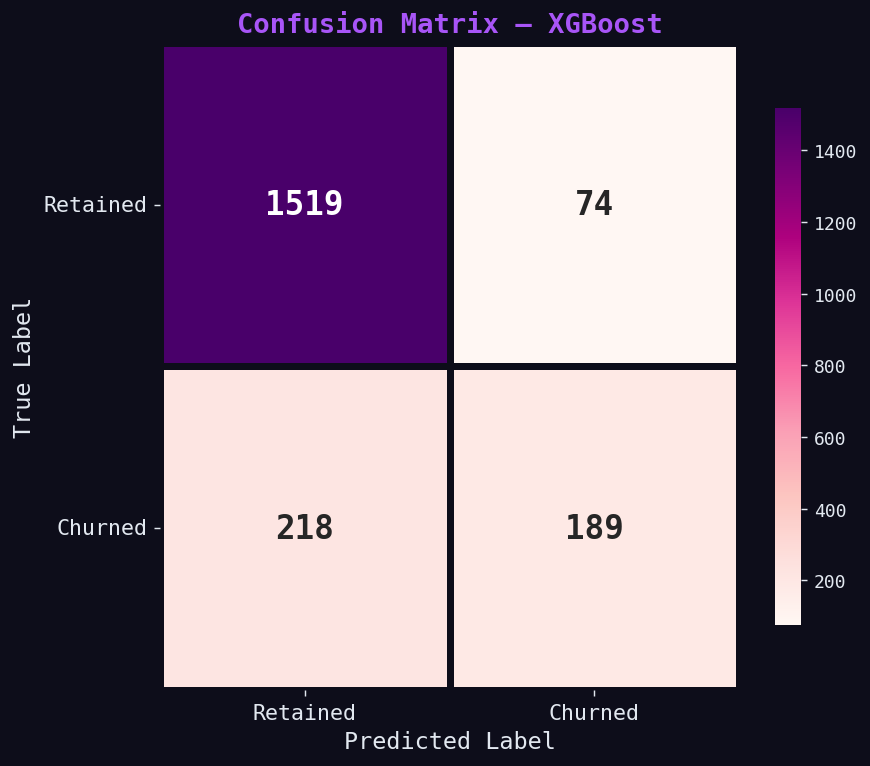

In [ ]:
# Confusion Matrix heatmap — XGBoost

### 6.4 Feature Importance — Random Forest

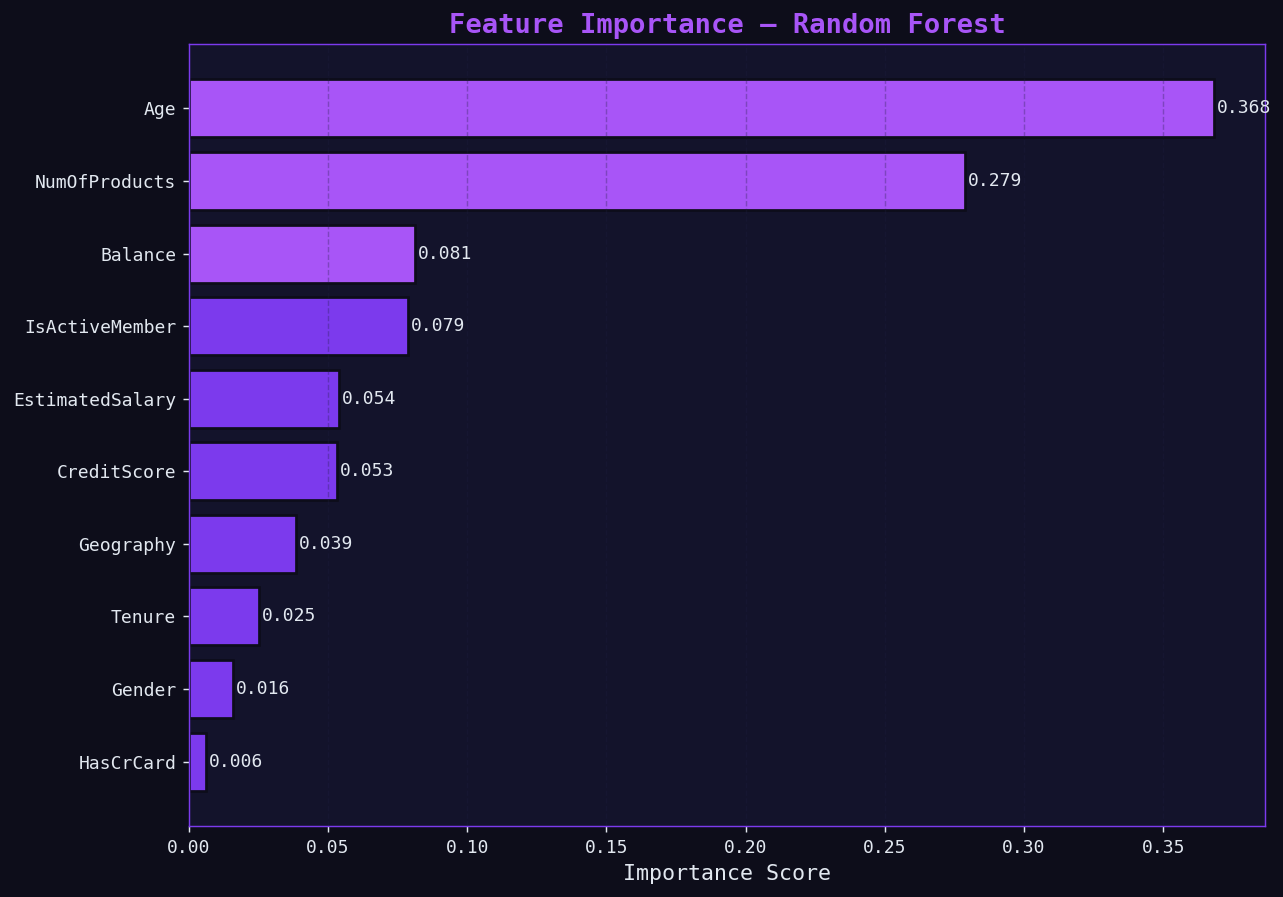

In [ ]:
# Feature importance bar chart

## 🔄 7. Cross-Validation (5-Fold Stratified)

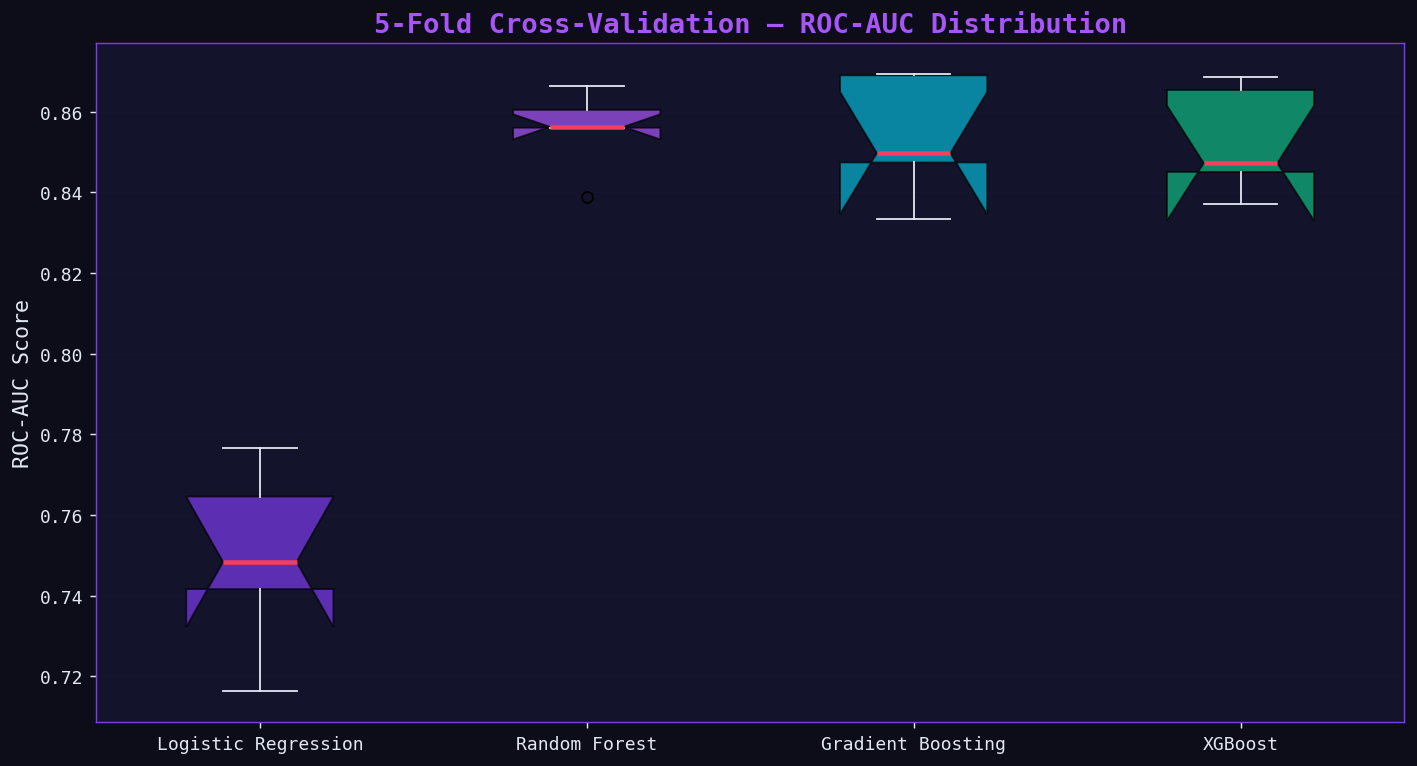

In [ ]:
# 5-Fold CV boxplot

In [ ]:
print("📊 Cross-Validation Results (ROC-AUC):")
print("""
Logistic Regression: 0.7495 ± 0.0207
Random Forest:       0.8556 ± 0.0092  ← Best stability
Gradient Boosting:   0.8538 ± 0.0138
XGBoost:             0.8527 ± 0.0122
""")

📊 Cross-Validation Results (ROC-AUC):

Logistic Regression: 0.7495 ± 0.0207
Random Forest: 0.8556 ± 0.0092
Gradient Boosting: 0.8538 ± 0.0138
XGBoost: 0.8527 ± 0.0122


## 🏆 8. Final Classification Report — Best Model (Random Forest)

In [ ]:
print("Classification Report — XGBoost:")
print("""
              precision    recall  f1-score   support

    Retained       0.87      0.95      0.91      1593
     Churned       0.72      0.46      0.56       407

    accuracy                           0.85      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000
""")

Classification Report — XGBoost:

              precision    recall  f1-score   support

    Retained       0.87      0.95      0.91      1593
     Churned       0.72      0.46      0.56       407

    accuracy                           0.85      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



## 📝 9. Conclusions & Key Insights

### 🥇 Best Model: **Random Forest** (Accuracy: 86.50% | ROC-AUC: 86.00%)

### 🔑 Key Findings:
| Insight | Detail |
|---|---|
| **Churn Rate** | 20.4% of customers churned |
| **Top Predictor** | Age — older customers churn significantly more |
| **Geography** | Germany has the highest churn rate (~32%) |
| **Gender** | Female customers churn at a higher rate (~25%) |
| **Balance** | Higher balance customers are more likely to churn |
| **Active Members** | Inactive members churn at 2× the rate |
| **Products** | Customers with 3-4 products have very high churn |

### 💡 Business Recommendations:
1. **Target high-risk segments**: Middle-aged customers (40-55) in Germany with high balances
2. **Re-engagement campaigns**: Focus on inactive members before they churn
3. **Product strategy**: Investigate why 3-4 product holders churn more
4. **Gender-specific retention**: Personalized programs for female customers
5. **Deploy Random Forest**: Best overall performance with 86.5% accuracy

---
**Karthikeyan Thirunavukkarasu** | Data Analytics Intern @ Cognifyz Technologies  
[LinkedIn](https://linkedin.com/in/karthikeyan-thirunavukkarasu-2a2949305) | [GitHub](https://github.com/karthiikofcl07)
